# Meeting Context Over Time

This notebook extends the earlier meeting-context work by comparing the `q24` meeting variables across **Wave 1**, **Wave 2**, and **Wave 3**.

The key caution is interpretive: these items describe **how the couple met**, so they should usually be fairly stable over time. If the reported meeting pathway changes across waves, that may reflect recall differences, questionnaire changes, cleaning choices, or attrition rather than a real behavioral change after the relationship began.


## 1. Setup

We load the panel data, keep the respondent identifier, and define the same broad meeting-context groups for all three waves.


In [44]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

data_filename = "HCMST 2017 to 2022 small public version 2.2.dta"
data_candidates = [
    Path("data") / data_filename,
    Path("../../data") / data_filename,
]
data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(f"Could not find {data_filename} in expected data directories.")

df = pd.read_stata(data_path).copy()

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


/tmp/ipykernel_10517/667379044.py:18: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df = pd.read_stata(data_path).copy()


## 2. Build Comparable Meeting Groups

To keep the comparison conservative, we use broad grouped indicators that can be reconstructed in each wave with the same logic.


In [45]:
meeting_groups = {
    "social": [
        "met_through_friend",
        "met_through_family",
        "met_through_as_nghbrs",
    ],
    "work": [
        "met_as_through_cowork",
        "customer",
        "work_neighbors",
        "business_trip",
    ],
    "online": [
        "met_online",
        "internet_dating",
        "internet_soc_network",
        "internet_other",
        "internet_game",
        "internet_chat",
        "internet_org",
    ],
    "leisure_public": [
        "bar_restaurant",
        "party",
        "public",
        "blind_date",
        "singles_serve_nonint",
        "vacation",
    ],
}

wave_prefixes = {1: "w1", 2: "w2", 3: "w3"}
weight_by_wave = {1: "w1_weight_combo", 2: "w2_combo_weight", 3: "w3_combo_weight"}

def available_columns(df, wave, suffixes):
    prefix = wave_prefixes[wave]
    cols = [f"{prefix}_q24_{suffix}" for suffix in suffixes]
    return [c for c in cols if c in df.columns]

def coerce_binary_series(series):
    non_missing = series.dropna()
    normalized = non_missing.astype(str).str.strip().str.lower()
    if not non_missing.empty and normalized.isin(["yes", "no"]).all():
        return (
            series.astype("string")
            .str.strip()
            .str.lower()
            .map({"yes": 1, "no": 0})
            .astype(float)
        )
    return pd.to_numeric(series, errors="coerce")

availability_rows = []
for wave in wave_prefixes:
    for group_name, suffixes in meeting_groups.items():
        cols = available_columns(df, wave, suffixes)
        availability_rows.append({
            "wave": f"Wave {wave}",
            "meeting_group": group_name,
            "expected_columns": len(suffixes),
            "available_columns": len(cols),
            "columns": ", ".join(cols),
        })

availability = pd.DataFrame(availability_rows)
availability


,wave,meeting_group,expected_columns,available_columns,columns
0,Wave 1,social,3,3,"w1_q24_met_through_friend, w1_q24_met_through_..."
1,Wave 1,work,4,4,"w1_q24_met_as_through_cowork, w1_q24_customer,..."
2,Wave 1,online,7,7,"w1_q24_met_online, w1_q24_internet_dating, w1_..."
3,Wave 1,leisure_public,6,6,"w1_q24_bar_restaurant, w1_q24_party, w1_q24_pu..."
4,Wave 2,social,3,3,"w2_q24_met_through_friend, w2_q24_met_through_..."
5,Wave 2,work,4,4,"w2_q24_met_as_through_cowork, w2_q24_customer,..."
6,Wave 2,online,7,7,"w2_q24_met_online, w2_q24_internet_dating, w2_..."
7,Wave 2,leisure_public,6,6,"w2_q24_bar_restaurant, w2_q24_party, w2_q24_pu..."
8,Wave 3,social,3,3,"w3_q24_met_through_friend, w3_q24_met_through_..."
9,Wave 3,work,4,4,"w3_q24_met_as_through_cowork, w3_q24_customer,..."


In [46]:
for wave in wave_prefixes:
    prefix = wave_prefixes[wave]
    for group_name, suffixes in meeting_groups.items():
        cols = available_columns(df, wave, suffixes)
        indicator = f"{prefix}_met_{group_name}"
        if not cols:
            df[indicator] = np.nan
            continue

        temp = df[cols].apply(coerce_binary_series)
        has_any_info = temp.notna().any(axis=1)
        any_yes = temp.fillna(0).sum(axis=1) > 0

        df[indicator] = np.where(has_any_info, any_yes.astype(int), np.nan)

indicator_cols = [
    f"{wave_prefixes[wave]}_met_{group_name}"
    for wave in wave_prefixes
    for group_name in meeting_groups
]

df[["caseid_new", "w1_same_sex_couple"] + indicator_cols].head()


,caseid_new,w1_same_sex_couple,w1_met_social,w1_met_work,w1_met_online,w1_met_leisure_public,w2_met_social,w2_met_work,w2_met_online,w2_met_leisure_public,w3_met_social,w3_met_work,w3_met_online,w3_met_leisure_public
0,53001,NOT same-sex souple,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN
1,71609,NOT same-sex souple,1.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,106983,NOT same-sex souple,0.0,1.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,121759,NOT same-sex souple,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,158083,NOT same-sex souple,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Coverage and Missingness by Wave

Before comparing waves, we check how much usable information exists for each grouped indicator.


In [47]:
coverage_rows = []
for wave in wave_prefixes:
    prefix = wave_prefixes[wave]
    weight_col = weight_by_wave[wave]
    for group_name in meeting_groups:
        col = f"{prefix}_met_{group_name}"
        coverage_rows.append({
            "wave": f"Wave {wave}",
            "meeting_group": group_name,
            "non_missing_n": int(df[col].notna().sum()),
            "missing_n": int(df[col].isna().sum()),
            "weight_non_missing_n": int(df[weight_col].notna().sum()),
        })

coverage = pd.DataFrame(coverage_rows)
coverage


,wave,meeting_group,non_missing_n,missing_n,weight_non_missing_n
0,Wave 1,social,3295,215,3510
1,Wave 1,work,3295,215,3510
2,Wave 1,online,3394,116,3510
3,Wave 1,leisure_public,3295,215,3510
4,Wave 2,social,141,3369,2107
5,Wave 2,work,141,3369,2107
6,Wave 2,online,141,3369,2107
7,Wave 2,leisure_public,141,3369,2107
8,Wave 3,social,90,3420,1722
9,Wave 3,work,90,3420,1722


## 3b. Diagnostic Check: Why Later-Wave Tables Can Look Empty

The later waves include `q24` variables in the dataset, but they are only populated for a small subset of respondents. In addition, some of the meeting indicators are stored as string values (`"yes"` / `"no"`) rather than numeric `1` / `0`, so a plain `pd.to_numeric(...)` coercion incorrectly turns valid responses into missing values. This block checks that directly before the weighted summaries.


In [48]:
df["w1_q24_met_online"].unique()

['no', 'yes', NaN]
Categories (2, str): ['no' < 'yes']

In [49]:
df["w1_q24_met_through_friend"].unique()

['no', 'yes', NaN]
Categories (2, str): ['no' < 'yes']

In [50]:
diagnostic_cols = [
    "w1_q24_length",
    "w2_q24_length",
    "w3_q24_length",
    "w2_q24_answered",
    "w1_q24_met_online",
    "w2_q24_met_online",
    "w3_q24_met_online",
    "w1_q24_met_through_friend",
    "w2_q24_met_through_friend",
    "w3_q24_met_through_friend",
]

diagnostic_rows = []

for col in diagnostic_cols:
    if col not in df.columns:
        continue

    series = df[col]

    # Detect yes/no columns
    if series.dropna().isin(["yes", "no"]).all():
        # Convert to numeric
        series_num = series.map({"yes": 1, "no": 0})

    else:
        # Keep numeric columns as they are
        series_num = pd.to_numeric(series, errors="coerce")

    diagnostic_rows.append({
        "variable": col,
        "non_missing_n": int(series_num.notna().sum()),
        "missing_n": int(series_num.isna().sum()),
        "ones_n": int((series_num == 1).sum()),
        "zeros_n": int((series_num == 0).sum()),
    })

diagnostics = pd.DataFrame(diagnostic_rows)
diagnostics


,variable,non_missing_n,missing_n,ones_n,zeros_n
0,w1_q24_length,3394,116,3,99
1,w2_q24_length,146,3364,1,0
2,w3_q24_length,90,3420,0,0
3,w2_q24_answered,3510,0,141,3369
4,w1_q24_met_online,3394,116,402,2992
5,w2_q24_met_online,141,3369,54,87
6,w3_q24_met_online,90,3420,26,64
7,w1_q24_met_through_friend,3295,215,928,2367
8,w2_q24_met_through_friend,141,3369,21,120
9,w3_q24_met_through_friend,90,3420,12,78


In [51]:
wave_q24_availability = pd.DataFrame({
    "Wave 1": {
        "usable q24 length": int(coerce_binary_series(df["w1_q24_length"]).notna().sum()),
        "usable met_online": int(coerce_binary_series(df["w1_q24_met_online"]).notna().sum()),
        "usable met_through_friend": int(coerce_binary_series(df["w1_q24_met_through_friend"]).notna().sum()),
    },
    "Wave 2": {
        "usable q24 length": int(coerce_binary_series(df["w2_q24_length"]).notna().sum()),
        "w2_q24_answered == 1": int((coerce_binary_series(df["w2_q24_answered"]) == 1).sum()),
        "usable met_online": int(coerce_binary_series(df["w2_q24_met_online"]).notna().sum()),
        "usable met_through_friend": int(coerce_binary_series(df["w2_q24_met_through_friend"]).notna().sum()),
    },
    "Wave 3": {
        "usable q24 length": int(coerce_binary_series(df["w3_q24_length"]).notna().sum()),
        "usable met_online": int(coerce_binary_series(df["w3_q24_met_online"]).notna().sum()),
        "usable met_through_friend": int(coerce_binary_series(df["w3_q24_met_through_friend"]).notna().sum()),
    },
}).fillna("")

wave_q24_availability


,Wave 1,Wave 2,Wave 3
usable q24 length,3394.0,146,90.0
usable met_online,3394.0,141,90.0
usable met_through_friend,3295.0,141,90.0
w2_q24_answered == 1,,141,


## 4. Weighted Meeting Shares by Wave

These summaries treat each wave as a separate weighted cross-section. This is the right place to compare how the distribution of reported meeting contexts looks in each wave.


In [52]:
def weighted_binary_mean(data, value_col, weight_col):
    if value_col not in data.columns or weight_col not in data.columns:
        return np.nan
    subset = data[[value_col, weight_col]].dropna()
    if subset.empty or subset[weight_col].sum() == 0:
        return np.nan
    return np.average(subset[value_col], weights=subset[weight_col])

share_rows = []
for wave in wave_prefixes:
    prefix = wave_prefixes[wave]
    weight_col = weight_by_wave[wave]
    for group_name in meeting_groups:
        col = f"{prefix}_met_{group_name}"
        share_rows.append({
            "wave": f"Wave {wave}",
            "meeting_group": group_name,
            "weighted_share": weighted_binary_mean(df, col, weight_col),
        })

wave_shares = pd.DataFrame(share_rows)
wave_shares["weighted_share_pct"] = (wave_shares["weighted_share"] * 100).round(1)
wave_shares.pivot(index="meeting_group", columns="wave", values="weighted_share_pct")


wave,Wave 1,Wave 2,Wave 3
meeting_group,,,
leisure_public,34.0,19.7,28.9
online,10.1,35.1,20.5
social,40.0,25.5,30.9
work,24.0,27.0,22.8


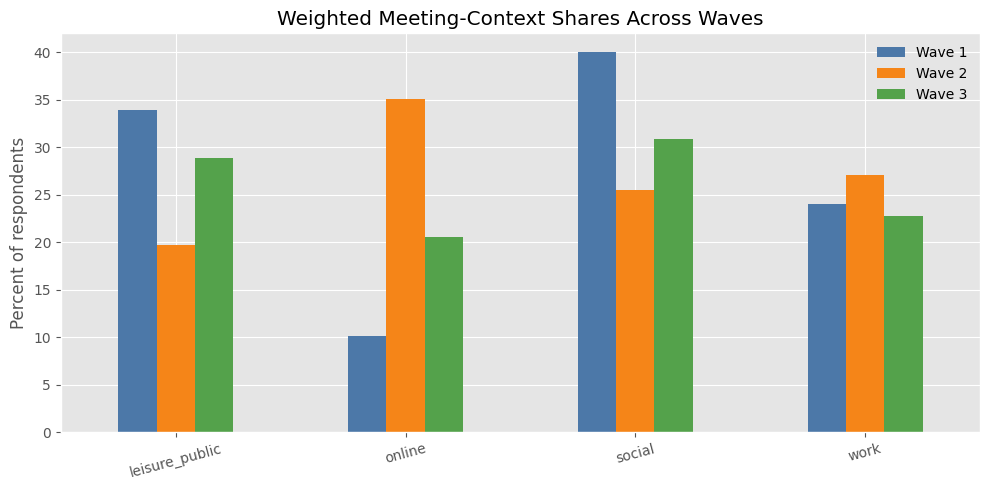

In [53]:
plot_table = wave_shares.pivot(index="meeting_group", columns="wave", values="weighted_share")
ax = (plot_table * 100).plot(kind="bar", figsize=(10, 5), color=["#4C78A8", "#F58518", "#54A24B"])
ax.set_title("Weighted Meeting-Context Shares Across Waves")
ax.set_ylabel("Percent of respondents")
ax.set_xlabel("")
ax.legend(title="", frameon=False)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 5. Weighted Shares by Couple Type and Wave

Here we keep the same baseline couple-type variable used in the other notebook. That means the subgroup definition comes from Wave 1, while the meeting reports come from each wave's `q24` block.


In [54]:
df["couple_type"] = (
    df["w1_same_sex_couple"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map({"same_sex_couple": "Same-sex couple", "not same-sex souple": "Different-sex couple"})
)

ctype_rows = []
for wave in wave_prefixes:
    prefix = wave_prefixes[wave]
    weight_col = weight_by_wave[wave]
    for group_name in meeting_groups:
        col = f"{prefix}_met_{group_name}"
        for couple_type, subset in df.groupby("couple_type", dropna=True):
            ctype_rows.append({
                "wave": f"Wave {wave}",
                "meeting_group": group_name,
                "couple_type": couple_type,
                "weighted_share": weighted_binary_mean(subset, col, weight_col),
            })

ctype_shares = pd.DataFrame(ctype_rows)
ctype_shares["weighted_share_pct"] = (ctype_shares["weighted_share"] * 100).round(1)
ctype_shares.head(12)


,wave,meeting_group,couple_type,weighted_share,weighted_share_pct
0,Wave 1,social,Different-sex couple,0.402903,40.3
1,Wave 1,social,Same-sex couple,0.288926,28.9
2,Wave 1,work,Different-sex couple,0.242035,24.2
3,Wave 1,work,Same-sex couple,0.161227,16.1
4,Wave 1,online,Different-sex couple,0.096135,9.6
5,Wave 1,online,Same-sex couple,0.302198,30.2
6,Wave 1,leisure_public,Different-sex couple,0.337927,33.8
7,Wave 1,leisure_public,Same-sex couple,0.401483,40.1
8,Wave 2,social,Different-sex couple,0.259724,26.0
9,Wave 2,social,Same-sex couple,0.131838,13.2


In [55]:
ctype_summary = ctype_shares.pivot_table(
    index=["meeting_group", "couple_type"],
    columns="wave",
    values="weighted_share_pct",
)
ctype_summary


wave                                 Wave 1  Wave 2  Wave 3
meeting_group  couple_type                                 
leisure_public Different-sex couple    33.8    20.0    30.9
               Same-sex couple         40.1    27.5    15.2
online         Different-sex couple     9.6    34.8    19.9
               Same-sex couple         30.2    56.6    24.8
social         Different-sex couple    40.3    26.0    34.3
               Same-sex couple         28.9    13.2     6.4
work           Different-sex couple    24.2    28.8    25.5
               Same-sex couple         16.1    10.9    18.2

## 6. Panel Consistency Within Respondents

This section asks a different question: among respondents with non-missing values in multiple waves, how often does the broad meeting classification stay the same? That is a better way to study longitudinal stability than treating the wave-to-wave differences as behavioral change.


In [56]:
stability_rows = []
for group_name in meeting_groups:
    w1_col = f"w1_met_{group_name}"
    w2_col = f"w2_met_{group_name}"
    w3_col = f"w3_met_{group_name}"

    complete_12 = df[[w1_col, w2_col]].dropna()
    complete_23 = df[[w2_col, w3_col]].dropna()
    complete_13 = df[[w1_col, w3_col]].dropna()
    complete_123 = df[[w1_col, w2_col, w3_col]].dropna()

    stability_rows.append({
        "meeting_group": group_name,
        "n_w1_w2": len(complete_12),
        "same_w1_w2": np.nan if complete_12.empty else (complete_12[w1_col] == complete_12[w2_col]).mean(),
        "n_w2_w3": len(complete_23),
        "same_w2_w3": np.nan if complete_23.empty else (complete_23[w2_col] == complete_23[w3_col]).mean(),
        "n_w1_w3": len(complete_13),
        "same_w1_w3": np.nan if complete_13.empty else (complete_13[w1_col] == complete_13[w3_col]).mean(),
        "n_all_three": len(complete_123),
        "same_all_three": np.nan if complete_123.empty else ((complete_123.nunique(axis=1) == 1).mean()),
    })

stability = pd.DataFrame(stability_rows)
pct_cols = ["same_w1_w2", "same_w2_w3", "same_w1_w3", "same_all_three"]
stability[pct_cols] = (stability[pct_cols] * 100).round(1)
stability


,meeting_group,n_w1_w2,same_w1_w2,n_w2_w3,same_w2_w3,n_w1_w3,same_w1_w3,n_all_three,same_all_three
0,social,133,60.9,10,80.0,82,68.3,9,66.7
1,work,133,69.2,10,90.0,82,74.4,9,66.7
2,online,135,64.4,10,80.0,83,79.5,10,70.0
3,leisure_public,133,66.2,10,80.0,82,62.2,9,44.4


In [57]:
change_rows = []
for group_name in meeting_groups:
    for left, right in [(1, 2), (2, 3), (1, 3)]:
        left_col = f"w{left}_met_{group_name}"
        right_col = f"w{right}_met_{group_name}"
        complete = df[[left_col, right_col]].dropna()
        if complete.empty:
            changed = np.nan
        else:
            changed = (complete[left_col] != complete[right_col]).mean()
        change_rows.append({
            "meeting_group": group_name,
            "comparison": f"W{left} to W{right}",
            "changed_pct": np.nan if pd.isna(changed) else round(changed * 100, 1),
            "n_complete": len(complete),
        })

changes = pd.DataFrame(change_rows)
changes.pivot(index="meeting_group", columns="comparison", values="changed_pct")


comparison,W1 to W2,W1 to W3,W2 to W3
meeting_group,,,
leisure_public,33.8,37.8,20.0
online,35.6,20.5,20.0
social,39.1,31.7,20.0
work,30.8,25.6,10.0


## 7. Interpretation Notes

A careful reading of this notebook would be:

- The cross-wave weighted summaries show whether the **distribution of reported meeting contexts** looks similar or different in each wave.
- The within-respondent agreement tables show whether those reports are **stable over time** for the same people.
- If the same respondent appears to change categories across waves, that should usually be interpreted as **reporting instability, measurement differences, or attrition effects**, not literal change in how the couple originally met.

Good next steps would be:

- checking whether the same patterns hold separately for different-sex and same-sex couples in the balanced panel only
- adding confidence intervals to the wave-specific weighted estimates
- testing sensitivity to narrower or broader meeting-group definitions
